### (H01) 일반 매장과 리저브 매장의 월평균 방문자 리뷰 수에는 차이가 없다.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# -------------------------------------------------------
# 데이터 파일 경로 설정
# -------------------------------------------------------
info_path   = r'C:\Users\cki68\OneDrive\바탕 화면\workspace\파이널 프로젝트\멋사 Final_Project_env\data\store_info.csv'
review_path = r'C:\Users\cki68\OneDrive\바탕 화면\workspace\파이널 프로젝트\멋사 Final_Project_env\data\store_review_summary.csv'


def load_csv_safely(path: str):
    """
    다양한 인코딩을 순서대로 시도해 CSV를 읽어오는 함수.
    
    한국어 CSV 파일은 인코딩이 파일마다 달라서 (utf-8, cp949 등)
    하나씩 시도해보고 성공하면 바로 반환하는 방식을 사용합니다.
    """
    file_name = os.path.basename(path)  # 경로에서 파일명만 추출 (출력용)

    for enc in ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ 성공: '{file_name}' → '{enc}' 인코딩")
            return df
        except UnicodeDecodeError:
            # 해당 인코딩으로 읽기 실패 → 다음 인코딩 시도
            continue

    print(f"❌ 실패: '{file_name}'을 읽지 못했습니다.")
    return None

store_info   = load_csv_safely(info_path)    # 매장 기본 정보 (이름, 타입, 오픈일 등)
store_review = load_csv_safely(review_path)  # 매장별 리뷰 요약 (리뷰 수 등)

# store_id + store_name 두 컬럼 기준으로 inner join
# inner join: 양쪽 데이터에 모두 존재하는 매장만 남김 (한쪽에만 있는 데이터는 제외)
df = pd.merge(store_info, store_review, on=['store_id', 'store_name'], how='inner')

print(f"\n병합 후 전체 매장 수: {len(df)}개")
df[['store_name', 'store_type', 'store_open_date', 'visitor_review_count']].head(3)

✅ 성공: 'store_info.csv' → 'utf-8-sig' 인코딩
✅ 성공: 'store_review_summary.csv' → 'cp949' 인코딩

병합 후 전체 매장 수: 2113개


,store_name,store_type,store_open_date,visitor_review_count
0,역삼아레나빌딩,일반 매장,20190613,3163
1,논현역사거리,일반 매장,20181123,4870
2,신사역성일빌딩,일반 매장,20191219,4359


In [3]:
# -------------------------------------------------------
# 전체 매장 중 일반 매장과 리저브 매장 개수
# -------------------------------------------------------
SPECIAL_STORES = [
    '광장마켓', '더여수돌산DT', '경동1960', '이대', '장충라운지R', '대구종로고택',
    '더북한산', '더북한강R', '더양평DT', '더춘천의암호R', '더제주송당파크R', '가나아트파크'
]

# 명시적 복사 (SettingWithCopyWarning 방지용)
df = df.copy()

# str.contains()로 store_type 컬럼에 '일반' 또는 '리저브' 문자열 포함 여부 확인
# na=False: NaN(빈 값)이 있어도 에러 없이 False로 처리
general_mask = df['store_type'].str.contains('일반', na=False)
reserve_mask = df['store_type'].str.contains('리저브', na=False)

print(f"전체 매장 중 일반 매장: {general_mask.sum()}개 | 리저브 매장: {reserve_mask.sum()}개")

전체 매장 중 일반 매장: 2050개 | 리저브 매장: 63개


In [4]:
import pandas as pd

# -------------------------------------------------------
# 분석 기준일 설정
# ⚠️ 반드시 실제 데이터 수집일과 일치시켜야 합니다.
# 기준일이 달라지면 모든 매장의 운영 개월 수가 바뀌고
# 결과적으로 월평균 리뷰 수 계산 전체가 영향을 받습니다.
# -------------------------------------------------------
CURRENT_DATE = pd.Timestamp('2026-02-13')

# 개점일 컬럼이 숫자형(예: 20190613)으로 저장되어 있으므로
# 문자열로 변환한 뒤 날짜 형식으로 파싱합니다.
df['store_open_date'] = pd.to_datetime(df['store_open_date'].astype(str), format='%Y%m%d')

# (기준일 - 개점일)로 경과 일수를 구한 뒤
# 한 달 평균 일수인 30.44로 나눠 '운영 개월 수'를 계산합니다.
df['months_since_open'] = (CURRENT_DATE - df['store_open_date']).dt.days / 30.44

# 총 리뷰 수 ÷ 운영 개월 수 = 월평균 방문자 리뷰 수
df['reviews_per_month'] = df['visitor_review_count'] / df['months_since_open']

# -------------------------------------------------------
# 데이터 품질 체크: 운영 개월 수가 0 이하인 이상값 제거
# (기준일보다 미래에 오픈한 매장 등 잘못된 데이터 방지)
# -------------------------------------------------------
invalid_count = (df['months_since_open'] <= 0).sum()
if invalid_count > 0:
    print(f"⚠️ 운영 개월 수 0 이하인 행 {invalid_count}개 제거")
    df = df[df['months_since_open'] > 0]

# 매장 타입별로 데이터프레임을 분리합니다.
# 이후 통계 분석과 시각화에서 이 두 변수를 사용합니다.
general_df = df[df['store_type'].str.contains('일반', na=False)]
reserve_df = df[df['store_type'].str.contains('리저브', na=False)]

print("\n[월평균 리뷰 수 계산 샘플 (상위 5개)]")
df[['store_name', 'store_type', 'visitor_review_count', 'months_since_open', 'reviews_per_month']].head(5)

⚠️ 운영 개월 수 0 이하인 행 1개 제거

[월평균 리뷰 수 계산 샘플 (상위 5개)]


,store_name,store_type,visitor_review_count,months_since_open,reviews_per_month
0,역삼아레나빌딩,일반 매장,3163,80.059133,39.508297
1,논현역사거리,일반 매장,4870,86.695138,56.173854
2,신사역성일빌딩,일반 매장,4359,73.850197,59.024893
3,국기원사거리,일반 매장,4668,78.482260,59.478409
4,대치재경빌딩,일반 매장,3604,83.968463,42.920876


In [5]:
# -------------------------------------------------------
# 기술통계 분석: 매장 유형별 월평균 리뷰 수 요약
# -------------------------------------------------------
desc_stats = df.groupby('store_type')['reviews_per_month'].describe().round(2)
desc_stats.columns = ['매장 수', '평균', '표준편차', '최솟값', '25%', '중앙값(50%)', '75%', '최댓값']
desc_stats.index.name = '매장 유형'

display(desc_stats)

,매장 수,평균,표준편차,최솟값,25%,중앙값(50%),75%,최댓값
매장 유형,,,,,,,,
리저브 매장,63.0,65.22,28.52,7.03,45.67,58.4,86.49,126.65
일반 매장,2049.0,37.10,24.45,0.28,20.94,33.9,49.11,405.93


### 탐색적 분석

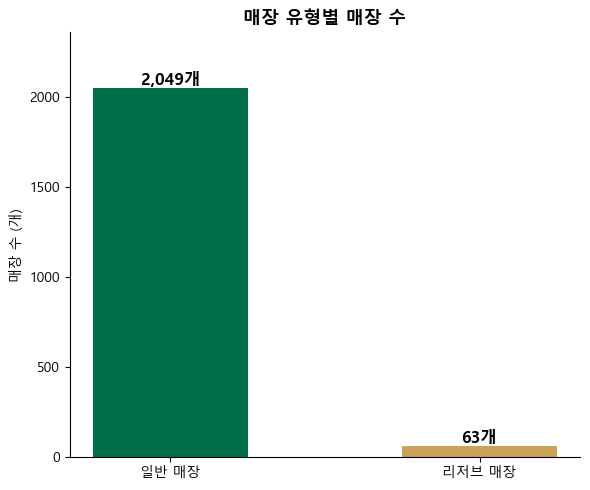


일반 매장: 2,049개 | 리저브 매장: 63개
→ 일반 매장이 리저브 매장보다 약 32배 많음 (표본 불균형 주의)


In [6]:
# -------------------------------------------------------
# EDA 1. 매장 수 비교 — 표본 불균형 시각화
# -------------------------------------------------------
store_counts = df['store_type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(store_counts.index, store_counts.values,
              color=['#00704A', '#CBA258'], width=0.5)

for bar, val in zip(bars, store_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{val:,}개', ha='center', fontsize=12, fontweight='bold')

ax.set_title('매장 유형별 매장 수', fontsize=13, fontweight='bold')
ax.set_ylabel('매장 수 (개)')
ax.set_ylim(0, store_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()
print(f"\n일반 매장: {store_counts.get('일반 매장', 0):,}개 | 리저브 매장: {store_counts.get('리저브 매장', 0)}개")
print(f"→ 일반 매장이 리저브 매장보다 약 {store_counts.get('일반 매장',0)//store_counts.get('리저브 매장',1)}배 많음 (표본 불균형 주의)")

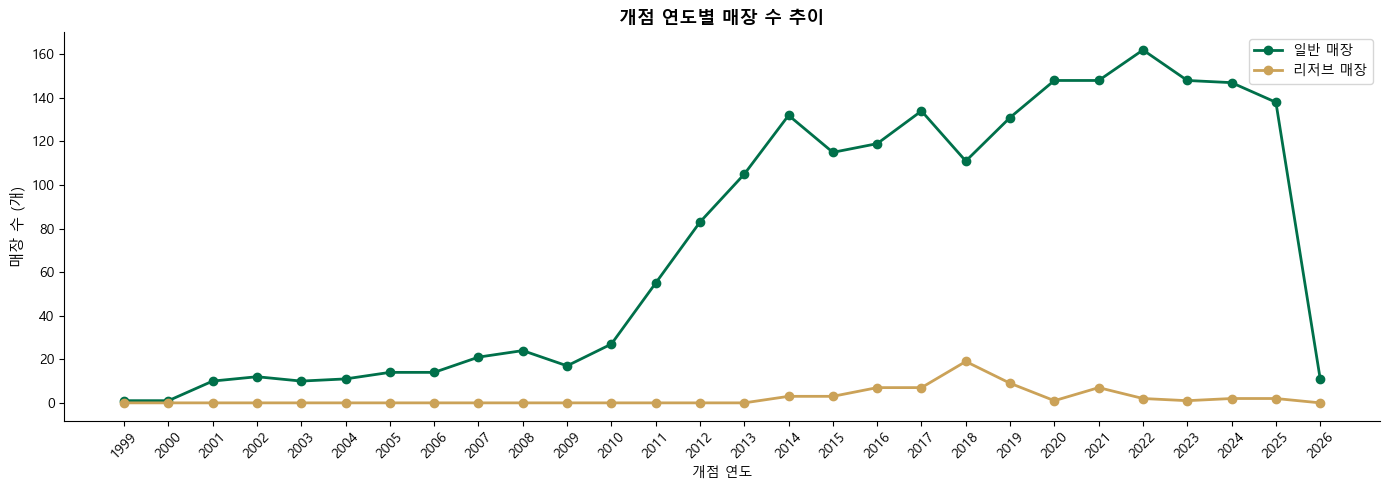

In [7]:
# -------------------------------------------------------
# EDA 2. 개점 연도별 매장 수 추이
# -------------------------------------------------------
df['open_year'] = df['store_open_date'].dt.year

yearly = df.groupby(['open_year', 'store_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(yearly.index, yearly.get('일반 매장', 0),
        color='#00704A', marker='o', linewidth=2, markersize=6, label='일반 매장')
ax.plot(yearly.index, yearly.get('리저브 매장', 0),
        color='#CBA258', marker='o', linewidth=2, markersize=6, label='리저브 매장')

ax.set_title('개점 연도별 매장 수 추이', fontsize=13, fontweight='bold')
ax.set_xlabel('개점 연도')
ax.set_ylabel('매장 수 (개)', fontsize=11)
ax.set_xticks(yearly.index)
ax.set_xticklabels(yearly.index, rotation=45)
ax.legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

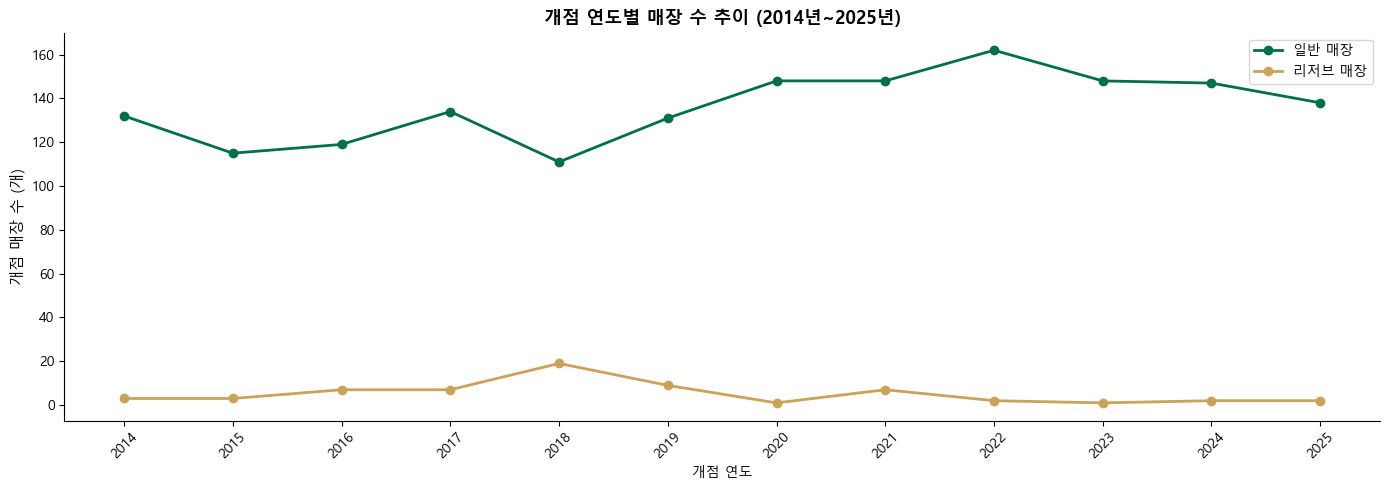

In [8]:
# -------------------------------------------------------
# EDA 2. 개점 연도별 매장 수 추이 (2014년 ~ 2025년)
# -------------------------------------------------------
# 1. 2014년부터 2025년 데이터만 필터링
yearly_filtered = yearly[(yearly.index >= 2014) & (yearly.index <= 2025)]

fig, ax = plt.subplots(figsize=(14, 5))

# 필터링된 데이터로 그래프 생성
if '일반 매장' in yearly_filtered.columns:
    ax.plot(yearly_filtered.index, yearly_filtered['일반 매장'],
            color='#00704A', marker='o', linewidth=2, markersize=6, label='일반 매장')

if '리저브 매장' in yearly_filtered.columns:
    ax.plot(yearly_filtered.index, yearly_filtered['리저브 매장'],
            color='#CBA258', marker='o', linewidth=2, markersize=6, label='리저브 매장')

ax.set_title('개점 연도별 매장 수 추이 (2014년~2025년)', fontsize=13, fontweight='bold')
ax.set_xlabel('개점 연도')
ax.set_ylabel('개점 매장 수 (개)', fontsize=11)
ax.set_xticks(yearly_filtered.index)
ax.set_xticklabels(yearly_filtered.index, rotation=45)
ax.legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

In [9]:
# -------------------------------------------------------
# [2-1] 연도별/매장타입별 신규 개점 수 수치 확인 (2014년 ~ 2025년)
# -------------------------------------------------------
print("\n[2014년~2025년 연도별 신규 개점 매장 수]")

# 2014년부터 2025년까지의 데이터 복사
summary_table = yearly_filtered.copy()

# 연도별 합계 계산
summary_table['합계'] = summary_table.sum(axis=1)

# 인덱스 이름 변경 및 출력
summary_table.index.name = '개점 연도'
display(summary_table)


[2014년~2025년 연도별 신규 개점 매장 수]


store_type,리저브 매장,일반 매장,합계
개점 연도,,,
2014,3,132,135
2015,3,115,118
2016,7,119,126
2017,7,134,141
2018,19,111,130
2019,9,131,140
2020,1,148,149
2021,7,148,155
2022,2,162,164


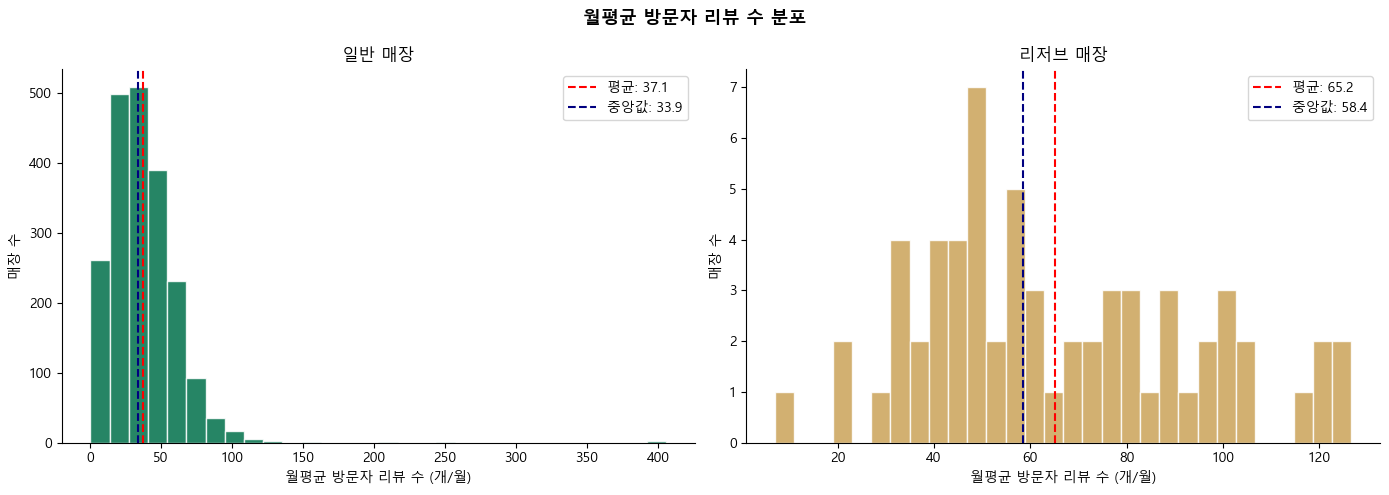

→ 두 집단 모두 오른쪽 꼬리(right-skewed) 분포 → 정규분포 가정 불가 → Mann-Whitney U 검정 적용 근거


In [10]:
# -------------------------------------------------------
# EDA 3. 월평균 리뷰 수 분포 — 히스토그램
# 편향된 분포 확인 → 비모수 검정(Mann-Whitney) 선택 근거
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('월평균 방문자 리뷰 수 분포', fontsize=13, fontweight='bold')

colors = {'일반 매장': '#00704A', '리저브 매장': '#CBA258'}

for ax, store_type in zip(axes, ['일반 매장', '리저브 매장']):
    data = df[df['store_type'] == store_type]['reviews_per_month']
    ax.hist(data, bins=30, color=colors[store_type], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'평균: {data.mean():.1f}')
    ax.axvline(data.median(), color='navy',   linestyle='--', linewidth=1.5, label=f'중앙값: {data.median():.1f}')
    ax.set_title(store_type, fontsize=12)
    ax.set_xlabel('월평균 방문자 리뷰 수 (개/월)')
    ax.set_ylabel('매장 수')
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()
print("→ 두 집단 모두 오른쪽 꼬리(right-skewed) 분포 → 정규분포 가정 불가 → Mann-Whitney U 검정 적용 근거")

C:\Users\cki68\AppData\Local\Temp\ipykernel_42564\2951799940.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax, x='Type', y='reviews_per_month',


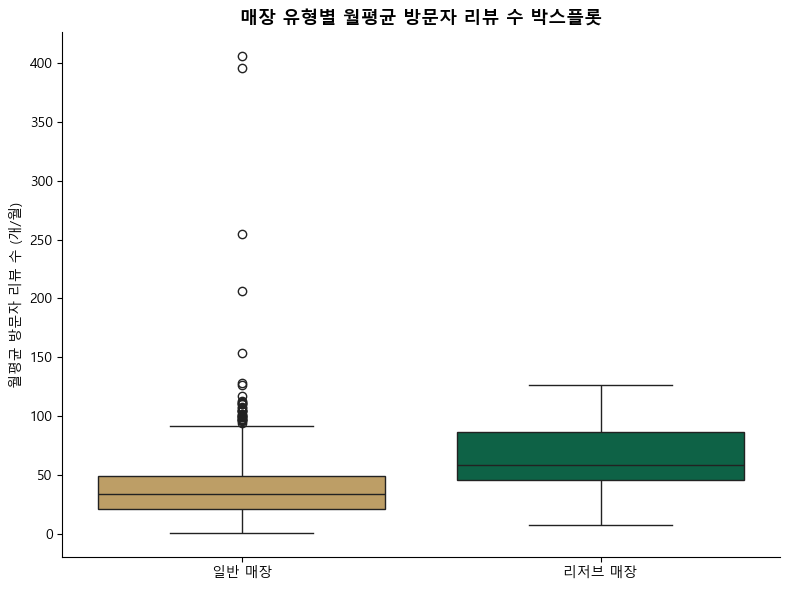

In [13]:
# -------------------------------------------------------
# EDA 4. 박스플롯 비교
# -------------------------------------------------------
plot_data = pd.concat([
    df[df['store_type'] == '일반 매장'].assign(Type='일반 매장'),
    df[df['store_type'] == '리저브 매장'].assign(Type='리저브 매장')
])

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(ax=ax, x='Type', y='reviews_per_month',
            data=plot_data, palette=['#CBA258', '#00704A'])

ax.set_title('매장 유형별 월평균 방문자 리뷰 수 박스플롯', fontsize=13, fontweight='bold')
ax.set_ylabel('월평균 방문자 리뷰 수 (개/월)')
ax.set_xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

In [14]:
# -------------------------------------------------------
# NaN 제거 후 각 그룹의 리뷰 수 시리즈 추출
# NaN이 있으면 mannwhitneyu 함수가 에러를 냄
# -------------------------------------------------------
gen_reviews = general_df['reviews_per_month'].dropna()
res_reviews = reserve_df['reviews_per_month'].dropna()
n1, n2 = len(gen_reviews), len(res_reviews)

# -------------------------------------------------------
# Mann-Whitney U 검정 수행
# - 정규분포를 가정하지 않는 비모수 검정
# - 두 집단의 값들을 섞어 순위를 매긴 뒤, 각 집단의 순위 합으로 차이를 비교
# - alternative='two-sided': "어느 쪽이든 차이가 있다"는 양측 검정
# -------------------------------------------------------
u_stat, p_val = stats.mannwhitneyu(gen_reviews, res_reviews, alternative='two-sided')

# -------------------------------------------------------
# 효과 크기: Rank-Biserial Correlation (r)
# - p-value는 "차이가 존재하는가?"만 알려주고 크기는 모름
# - r은 그 차이가 실질적으로 얼마나 큰지를 -1 ~ 1 사이로 표현
# - 양수: 일반 매장 순위가 더 높음 / 음수: 리저브 매장 순위가 더 높음
# - 수식: r = 1 - (2 * U) / (n1 * n2)
# - abs()를 쓰지 않아야 방향성이 보존됩니다!
# -------------------------------------------------------
r = 1 - (2 * u_stat) / (n1 * n2)
abs_r = abs(r)

# 효과 크기 해석 기준 (Cohen's guideline 기반)
if abs_r < 0.1:   effect_label = '무시 가능한 수준'
elif abs_r < 0.3: effect_label = '작은 효과'
elif abs_r < 0.5: effect_label = '중간 효과'
else:             effect_label = '큰 효과'

# r의 부호로 어느 집단의 순위가 더 높은지 판단
direction = '일반 매장' if r > 0 else '리저브 매장'

# -------------------------------------------------------
# 결과 출력
# -------------------------------------------------------
print("=" * 55)
print("       [최종 통계 분석 결과]")
print("=" * 55)
print(f" 일반 매장   │ n={n1:,}  │ 중앙값: {gen_reviews.median():.2f}개/월")
print(f" 리저브 매장 │ n={n2:,}   │ 중앙값: {res_reviews.median():.2f}개/월")
print("-" * 55)
print(f" U 통계량    : {u_stat:,.1f}")
print(f" P-value     : {p_val:.4f}  {'→ 귀무가설 기각 ✅' if p_val < 0.05 else '→ 귀무가설 채택 ❌'}")
print(f" 효과 크기 r : {r:.4f}  ({effect_label}, 방향: {direction}이 더 높은 순위)")
print("=" * 55)

print("\n[결론]")
if p_val < 0.05:
    print(f" → 귀무가설을 기각합니다. (p = {p_val:.4f} < 0.05)")
    print(f" → 리저브 매장(중앙값 {res_reviews.median():.1f}개)이 일반 매장(중앙값 {gen_reviews.median():.1f}개)보다")
    print(f"   월평균 방문자 리뷰 수가 통계적으로 유의미하게 많습니다.")
    print(f" → 효과 크기 r = {r:.2f}로 실질적으로도 큰 차이입니다.")
else:
    print(" → 귀무가설을 기각할 수 없습니다.")

print("\n[해석 시 주의사항]")
print(f" ⚠️ 표본 불균형: 일반({n1:,}개) vs 리저브({n2}개) — 리저브 매장 수가 적어")
print( "    결과를 전체 리저브 매장으로 일반화할 때는 신중해야 합니다.")
print( " ⚠️ 리뷰 수 ≠ 방문자 수이므로, 실제 방문 빈도와 직접 연결하지 않도록 주의하세요.")

       [최종 통계 분석 결과]
 일반 매장   │ n=2,049  │ 중앙값: 33.90개/월
 리저브 매장 │ n=63   │ 중앙값: 58.40개/월
-------------------------------------------------------
 U 통계량    : 26,873.0
 P-value     : 0.0000  → 귀무가설 기각 ✅
 효과 크기 r : 0.5836  (큰 효과, 방향: 일반 매장이 더 높은 순위)

[결론]
 → 귀무가설을 기각합니다. (p = 0.0000 < 0.05)
 → 리저브 매장(중앙값 58.4개)이 일반 매장(중앙값 33.9개)보다
   월평균 방문자 리뷰 수가 통계적으로 유의미하게 많습니다.
 → 효과 크기 r = 0.58로 실질적으로도 큰 차이입니다.

[해석 시 주의사항]
 ⚠️ 표본 불균형: 일반(2,049개) vs 리저브(63개) — 리저브 매장 수가 적어
    결과를 전체 리저브 매장으로 일반화할 때는 신중해야 합니다.
 ⚠️ 리뷰 수 ≠ 방문자 수이므로, 실제 방문 빈도와 직접 연결하지 않도록 주의하세요.


In [15]:
# 월평균 리뷰 수가 가장 높은 상위 10개 매장 확인
top_outliers = df.sort_values(by='reviews_per_month', ascending=False).head(10)
display(top_outliers[['store_name', 'store_type', 'reviews_per_month', 'visitor_review_count', 'months_since_open']])

,store_name,store_type,reviews_per_month,visitor_review_count,months_since_open
540,한국프레스센터,일반 매장,405.934142,48128,118.561104
566,무교로,일반 매장,395.546777,25118,63.501971
1121,송내역,일반 매장,254.461915,43837,172.273325
1295,대구신천DT,일반 매장,205.938768,5162,25.065703
1154,더양평DT,일반 매장,153.504571,10237,66.688568
619,경동1960,일반 매장,127.900710,4853,37.943495
1449,서면중앙대로R,리저브 매장,126.650567,10048,79.336399
1601,울산국가정원,일반 매장,126.342535,8023,63.501971
461,더현대서울(B2)R,리저브 매장,124.627901,7431,59.625493
829,수원역AK R,리저브 매장,122.247196,6273,51.314060
